# 02 — Interprétabilité : que regardent nos modèles pour décider d'un « oui » ?

**Question métier (HEC Match)** : quand l'app estime que A dira « oui » à B, sur quoi se fonde-t-elle ?
Peut-on l'expliquer à un utilisateur (droit à l'explication, RGPD / AI Act) et à l'équipe produit ?

**Modèles expliqués** (les versions de référence de la soutenance, sans proxies raciaux) :

| Modèle | Méthodes d'interprétation | Remarque |
|---|---|---|
| XGBoost mitigé | SHAP global et local (exact, TreeExplainer), PDP / ICE, LIME, permutation importance | modèle recommandé par la fairness |
| Logit (white box) | odds ratios, effets marginaux moyens, IC par bootstrap de sessions | **ré-entraîné proprement** sur `features_logit` sans les 4 proxies : `logit_mitigated.joblib` a été entraîné sur l'ancien schéma (colinéarité `shar1_1` + colonnes de référence des dummies), donc ses coefficients ne sont pas interprétables tels quels |
| TabICL mitigé | modèle surrogate sur ses prédictions figées | ne se charge que sur GPU (Colab) : interprétation post-hoc uniquement |

Toutes les analyses sont faites sur l'**échantillon test** (sessions 1, 2, 6, 9, 16, 18), sauf l'ajustement du logit (train).
Le code est dans `src/interpretability.py` ; les figures et tableaux dans `reports/interpretability/`.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import roc_auc_score

from src.interpretability import *

pd.set_option("display.max_colwidth", 60)
OUT_DIR.mkdir(parents=True, exist_ok=True)
summary = {}

## 1. Chargement

In [2]:
ctx = load_context()
train, test, F, xgb, fd = ctx["train"], ctx["test"], ctx["features"], ctx["xgb"], ctx["feature_dict"]
X = test[F]
print(f"train {train.shape} | test {test.shape} | variables XGBoost mitigé : {len(F)}")
print("AUC test :", {m: round(roc_auc_score(test.dec, test[f"proba_{m}"]), 3)
                     for m in ["logit_mitigated", "xgb_mitigated", "tabicl_mitigated"]})

train (6542, 180) | test (1826, 180) | variables XGBoost mitigé : 160
AUC test : {'logit_mitigated': np.float64(0.58), 'xgb_mitigated': np.float64(0.612), 'tabicl_mitigated': np.float64(0.626)}


## 2. SHAP global — XGBoost mitigé

SHAP répartit chaque prédiction entre les variables (valeurs de Shapley, slide 139 du cours).
On vérifie d'abord la propriété d'**efficacité** : la somme des contributions SHAP + la valeur de base
redonne exactement la prédiction du modèle (en log-odds) — c'est ce que teste `shap_values()`.

In [3]:
exp, base_value = shap_values(xgb, X)
imp = global_importance(exp.values, F)
imp.to_csv(OUT_DIR / "shap_global_xgb_mitigated.csv", index=False)
print(f"Valeur de base : {base_value:.3f} log-odds = P(oui) {sigmoid(base_value):.1%}")
imp.head(15)[["label", "side", "category", "mean_abs_shap", "share"]].round(3)

/home/claude/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Valeur de base : -0.335 log-odds = P(oui) 41.7%


,label,side,category,mean_abs_shap,share
0,A : importance même origine,A (décideur),Démographie / habitudes,0.128,0.032
1,A : aime les jeux vidéo,A (décideur),Intérêts,0.119,0.030
2,A : aime le cinéma,A (décideur),Intérêts,0.112,0.028
3,B : aime le sport,B (candidat),Intérêts,0.101,0.025
4,A : optimisme sur la soirée,A (décideur),Démographie / habitudes,0.094,0.023
5,B : revenu médian du quartier,B (candidat),Démographie / habitudes,0.087,0.022
6,A : âge,A (décideur),Démographie / habitudes,0.085,0.021
7,A : cherche : sincérité,A (décideur),Ce que je cherche,0.084,0.021
8,B : cherche : intérêts communs,B (candidat),Ce que je cherche,0.083,0.020
9,B : aime la TV,B (candidat),Intérêts,0.081,0.020


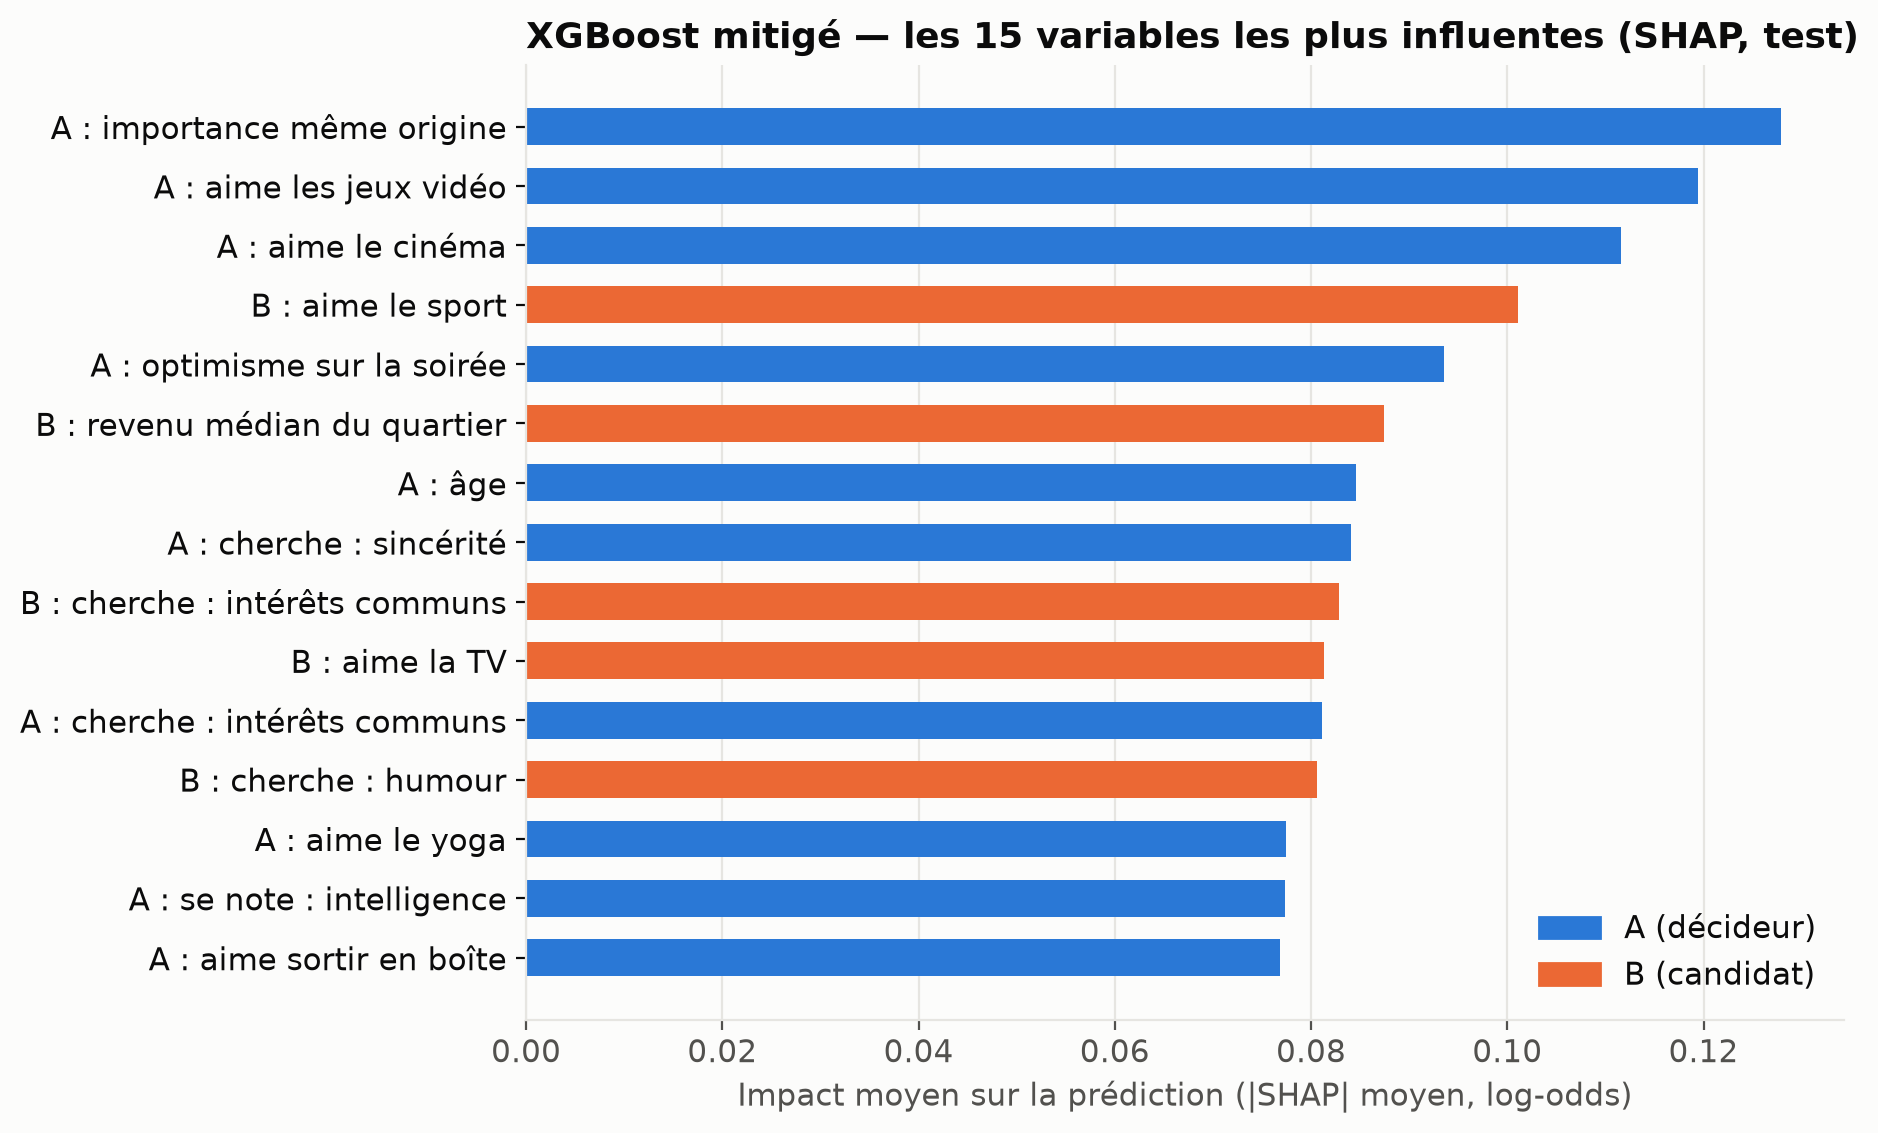

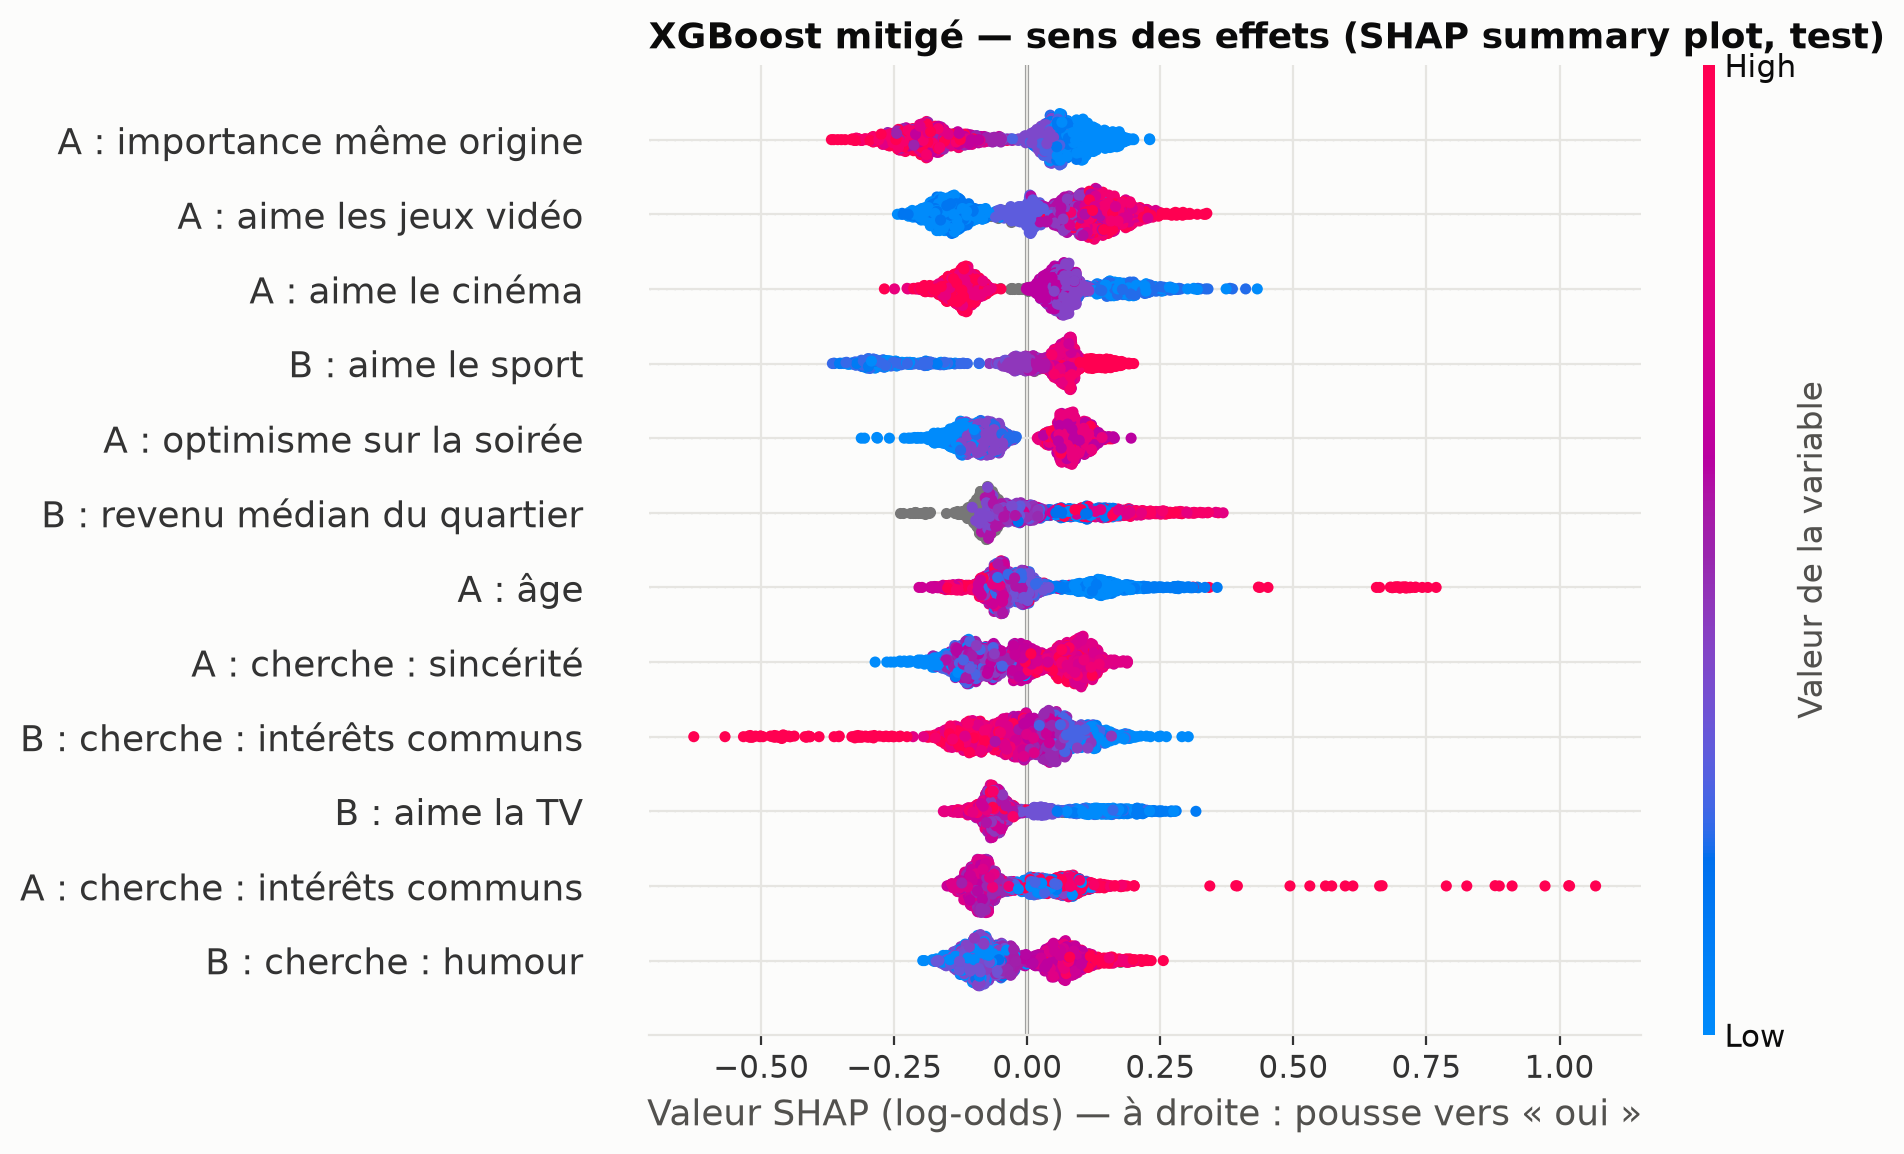

,feature,label,spearman_value_vs_shap,effet
0,imprace_A,A : importance même origine,-0.92,↓ moins de oui
1,gaming_A,A : aime les jeux vidéo,0.92,↑ plus de oui
2,movies_A,A : aime le cinéma,-0.93,↓ moins de oui
3,sports_B,B : aime le sport,0.91,↑ plus de oui
4,exphappy_A,A : optimisme sur la soirée,0.84,↑ plus de oui
5,income_B,B : revenu médian du quartier,0.24,non monotone
6,age_A,A : âge,-0.74,↓ moins de oui
7,sinc1_1_A,A : cherche : sincérité,0.84,↑ plus de oui
8,shar1_1_B,B : cherche : intérêts communs,-0.94,↓ moins de oui
9,tv_B,B : aime la TV,-0.71,↓ moins de oui


In [4]:
display(Image(plot_global_importance(imp)))
display(Image(plot_beeswarm(exp, X, imp)))
direction = direction_table(exp.values, X, F, imp.feature.head(15))
direction.to_csv(OUT_DIR / "shap_direction_top15.csv", index=False)
direction

**Lecture.** L'importance est **très diffuse** : la première variable ne pèse qu'environ 3 % du total,
cohérent avec une AUC modeste (~0,61). Les effets les plus nets (corrélation valeur ↔ SHAP > 0,8 en valeur absolue) :

- **A accorde de l'importance à la même origine → dit moins souvent oui.** C'est la variable n° 1 du modèle.
  Elle ne révèle pas l'origine de B, mais elle fait entrer la préférence raciale *déclarée* de l'utilisateur dans la
  recommandation : point à discuter avec la fairness (variable classée « borderline » dans `features.json`).
- **A est optimiste sur la soirée → dit plus souvent oui** ; A plus âgé → moins de oui.
- Côté candidat, B qui aime le sport reçoit plus de oui, B qui cherche surtout des intérêts communs en reçoit moins.

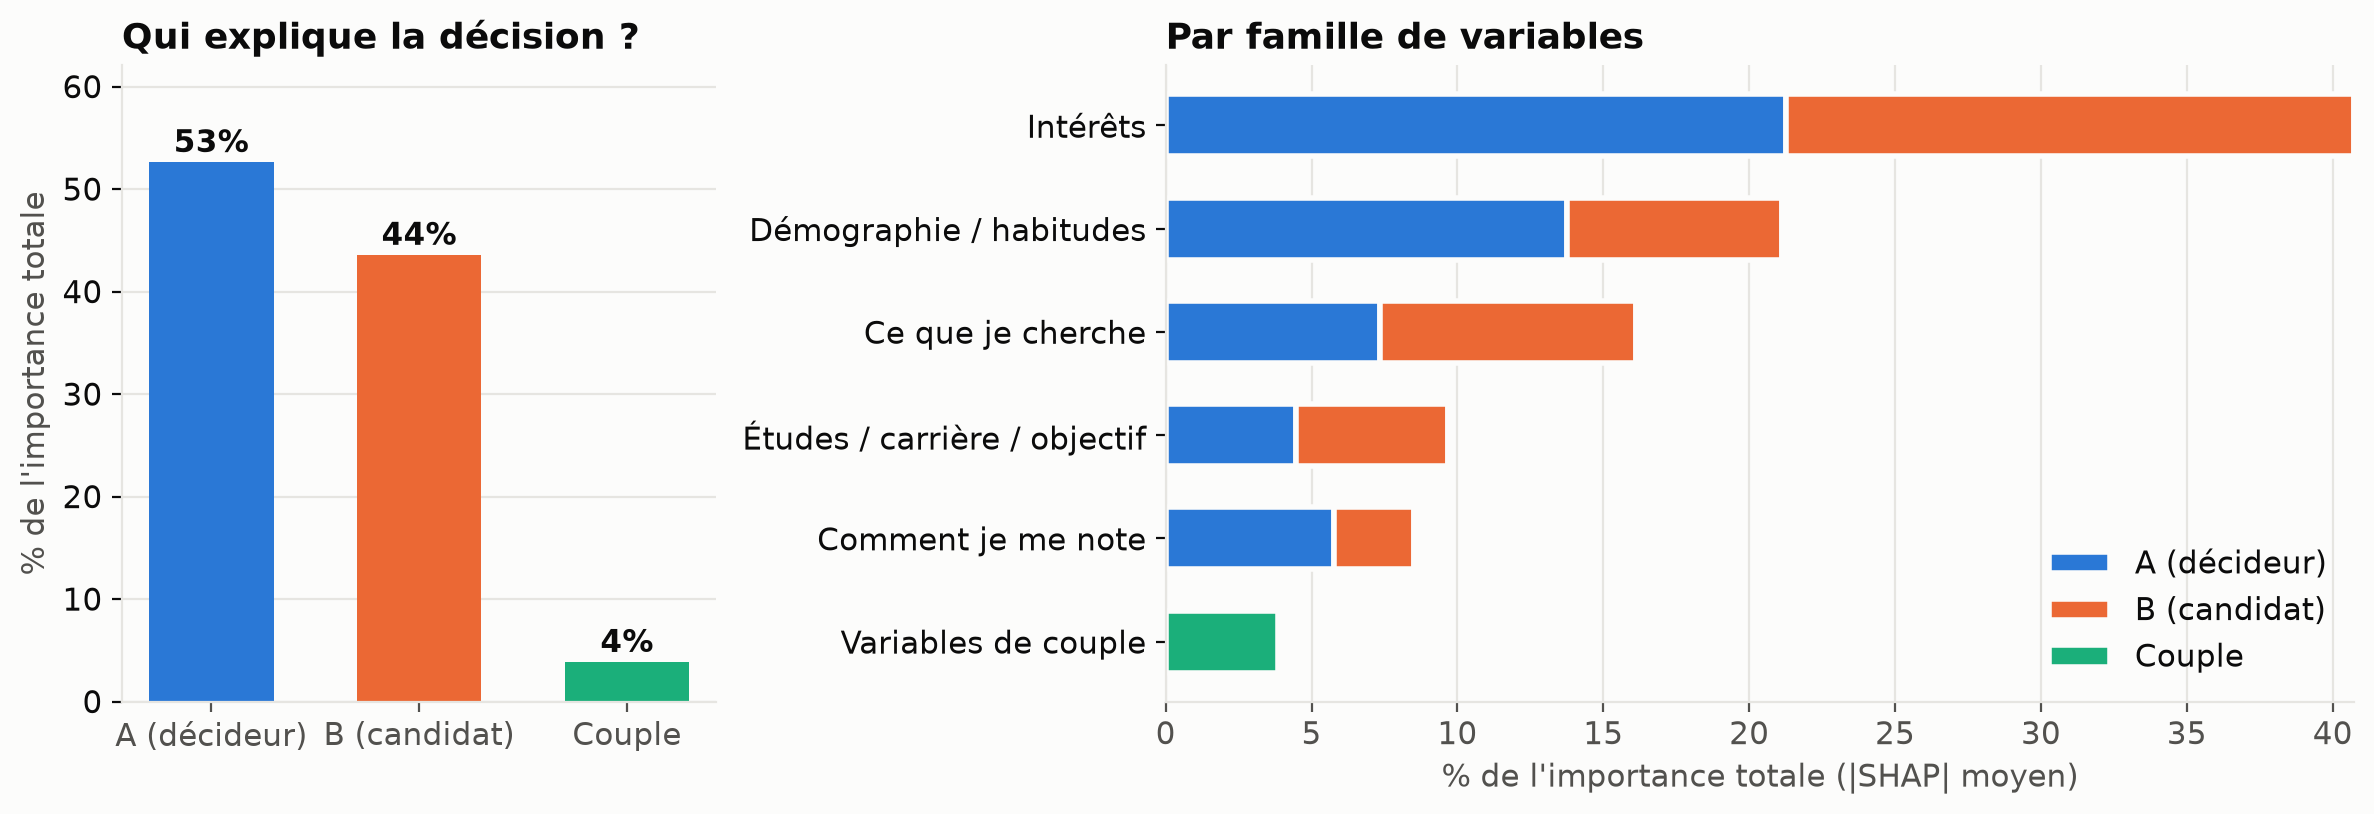

Part de l'importance : {'A (décideur)': 0.5260000228881836, 'B (candidat)': 0.4359999895095825, 'Couple': 0.03799999877810478}
Borne haute « sélectivité de A + popularité de B » (leave-one-out) : {'auc_selectivite_A': np.float64(0.763), 'auc_popularite_B': np.float64(0.744), 'auc_A_plus_B': np.float64(0.839)}


In [5]:
display(Image(plot_side_and_category(imp)))
side_share = imp.groupby("side").share.sum().round(3).to_dict()
bound = pickiness_popularity_bound(test)
summary["shap_share_by_side"] = side_share
summary["shap_share_by_category"] = imp.groupby("category").share.sum().round(3).to_dict()
summary["borne_selectivite_popularite"] = bound
print("Part de l'importance :", side_share)
print("Borne haute « sélectivité de A + popularité de B » (leave-one-out) :", bound)

**Message clé pour la soutenance.** Le modèle explique la décision surtout par **qui est A** (sa sélectivité)
et **qui est B** (sa popularité), presque jamais par **le couple** (compatibilité, écart d'âge, intérêts communs : ~4 %).

La borne ci-dessus le confirme : connaître seulement la sélectivité de A et la popularité de B, estimées sur les
*autres* rendez-vous de la soirée (sans la ligne prédite), donnerait une AUC d'environ 0,84, contre ~0,61 pour nos modèles.
Ce n'est pas un modèle déployable (il utilise les décisions de la soirée), mais cela montre que **la décision est
prévisible par le comportement, pas par le profil** : c'est le problème du *cold start* de toute app de rencontre.

## 3. Explications locales — pourquoi CE couple ?

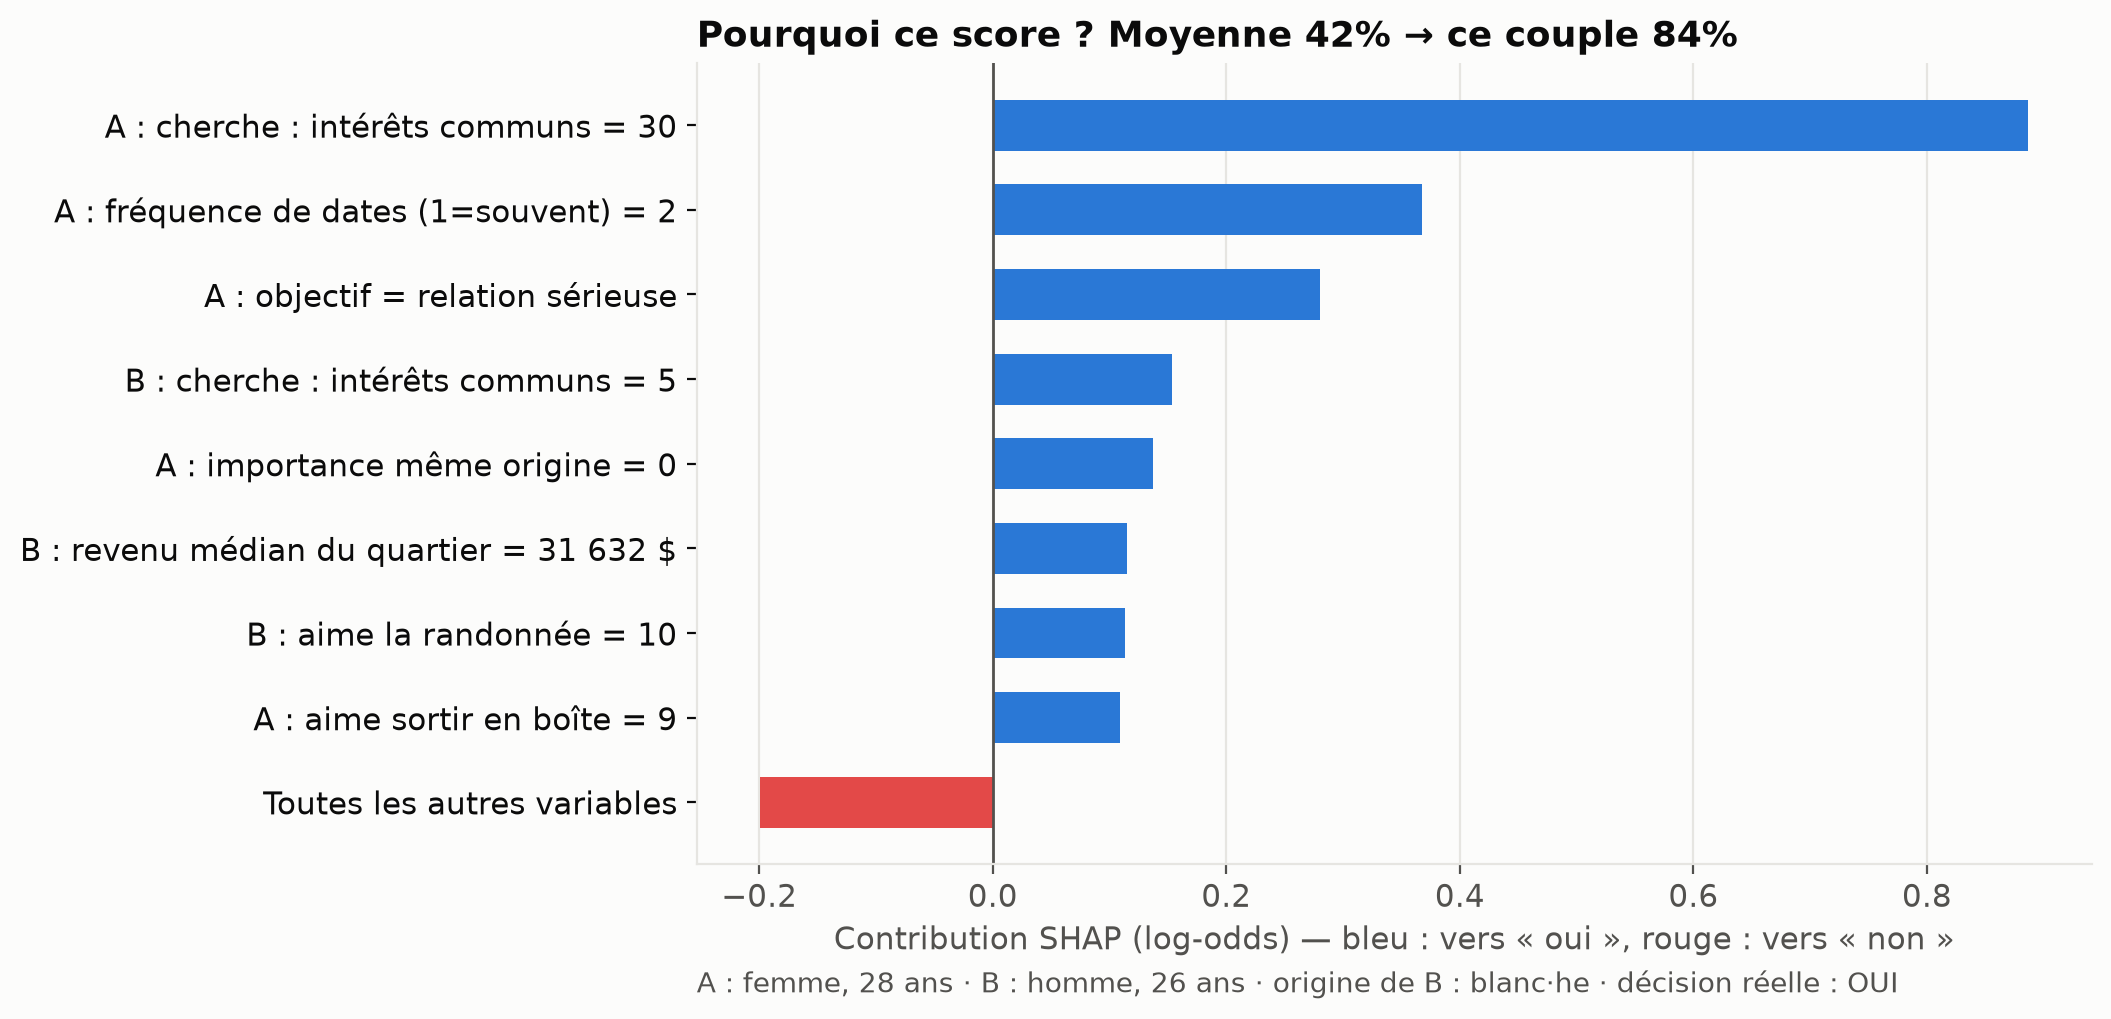

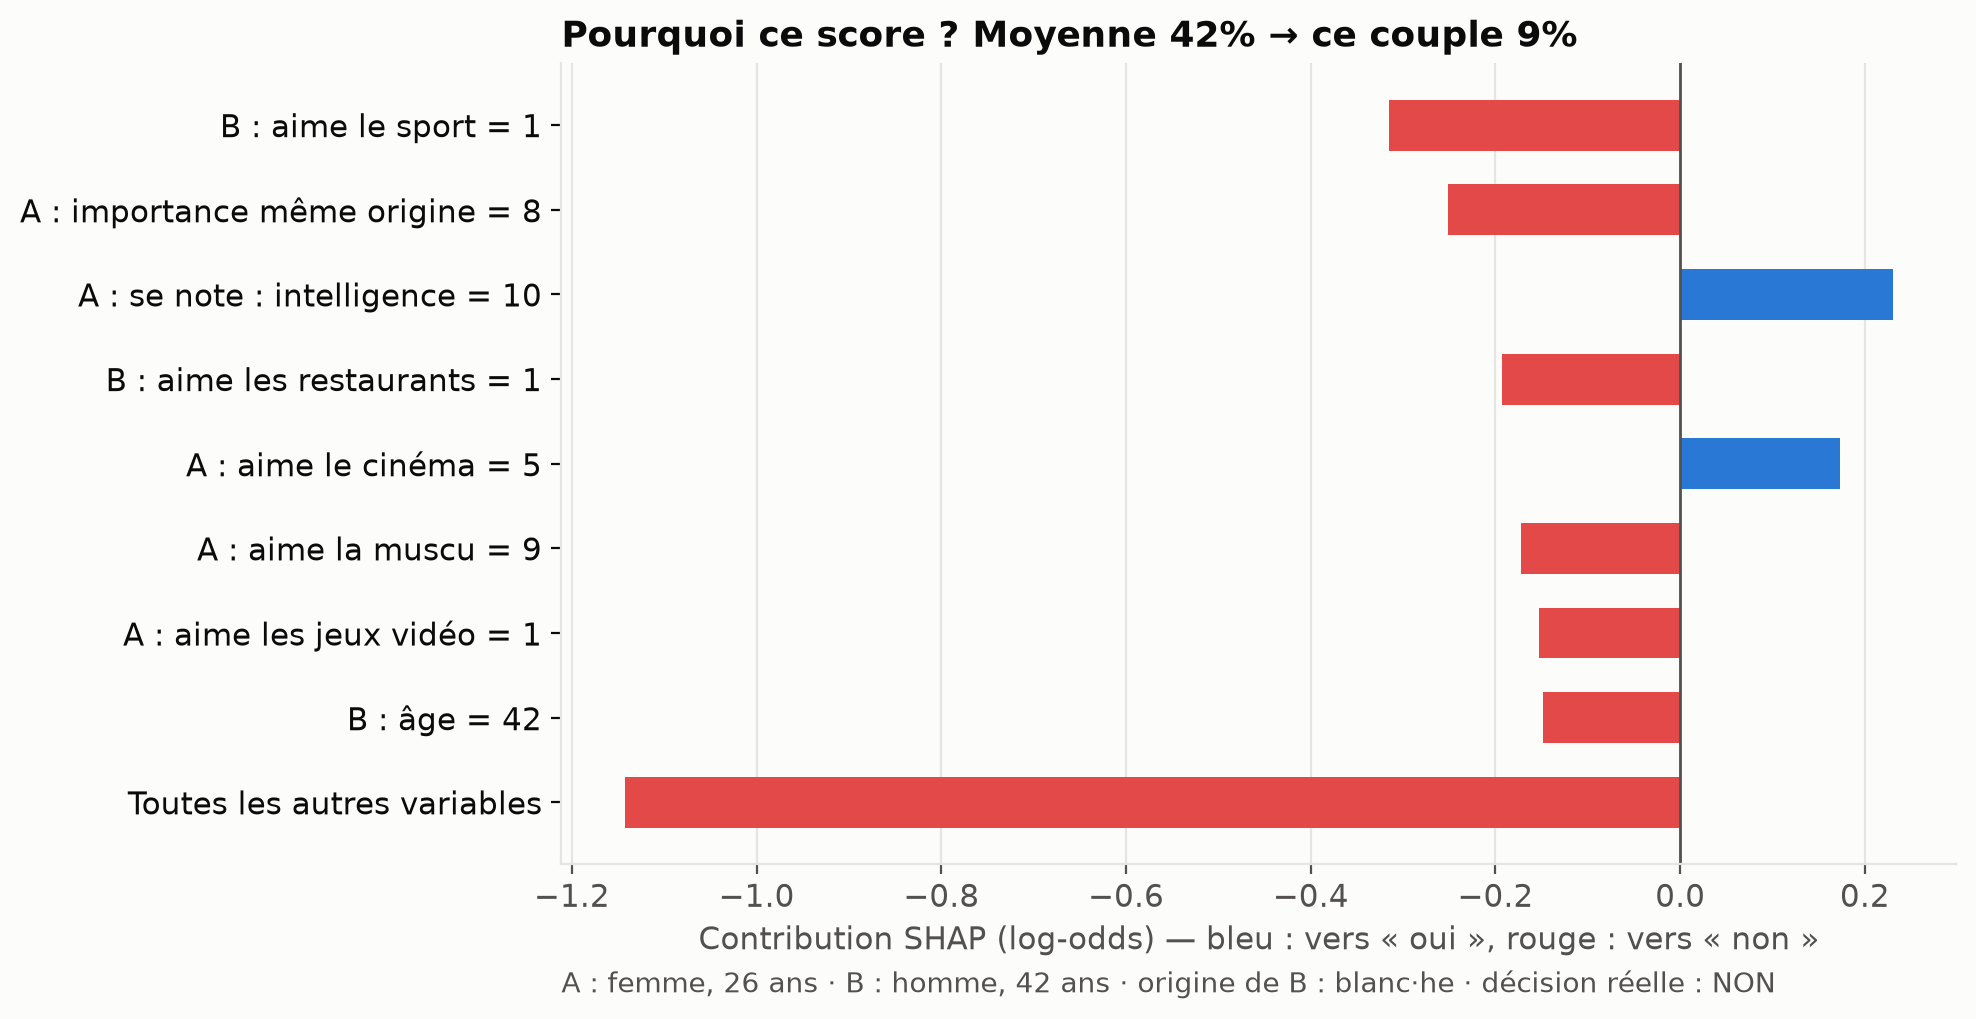

In [6]:
examples = pick_examples(test)
local_info = {}
for name, idx in examples.items():
    path, info = plot_local_shap(exp, base_value, test, idx, F, f"04_local_shap_{name}")
    local_info[name] = info
    display(Image(path))
summary["exemples_locaux"] = local_info

C'est ce que l'app pourrait afficher à l'utilisateur : « ce profil vous est proposé parce que… ».
La somme des barres, ajoutée à la probabilité moyenne, donne exactement le score du couple.

## 4. LIME vs SHAP — le *disagreement problem*

LIME ajuste un modèle linéaire autour du couple (slide 103). On compare sur les deux mêmes couples,
puis sur 100 couples tirés au hasard (Krishna et al., 2022).

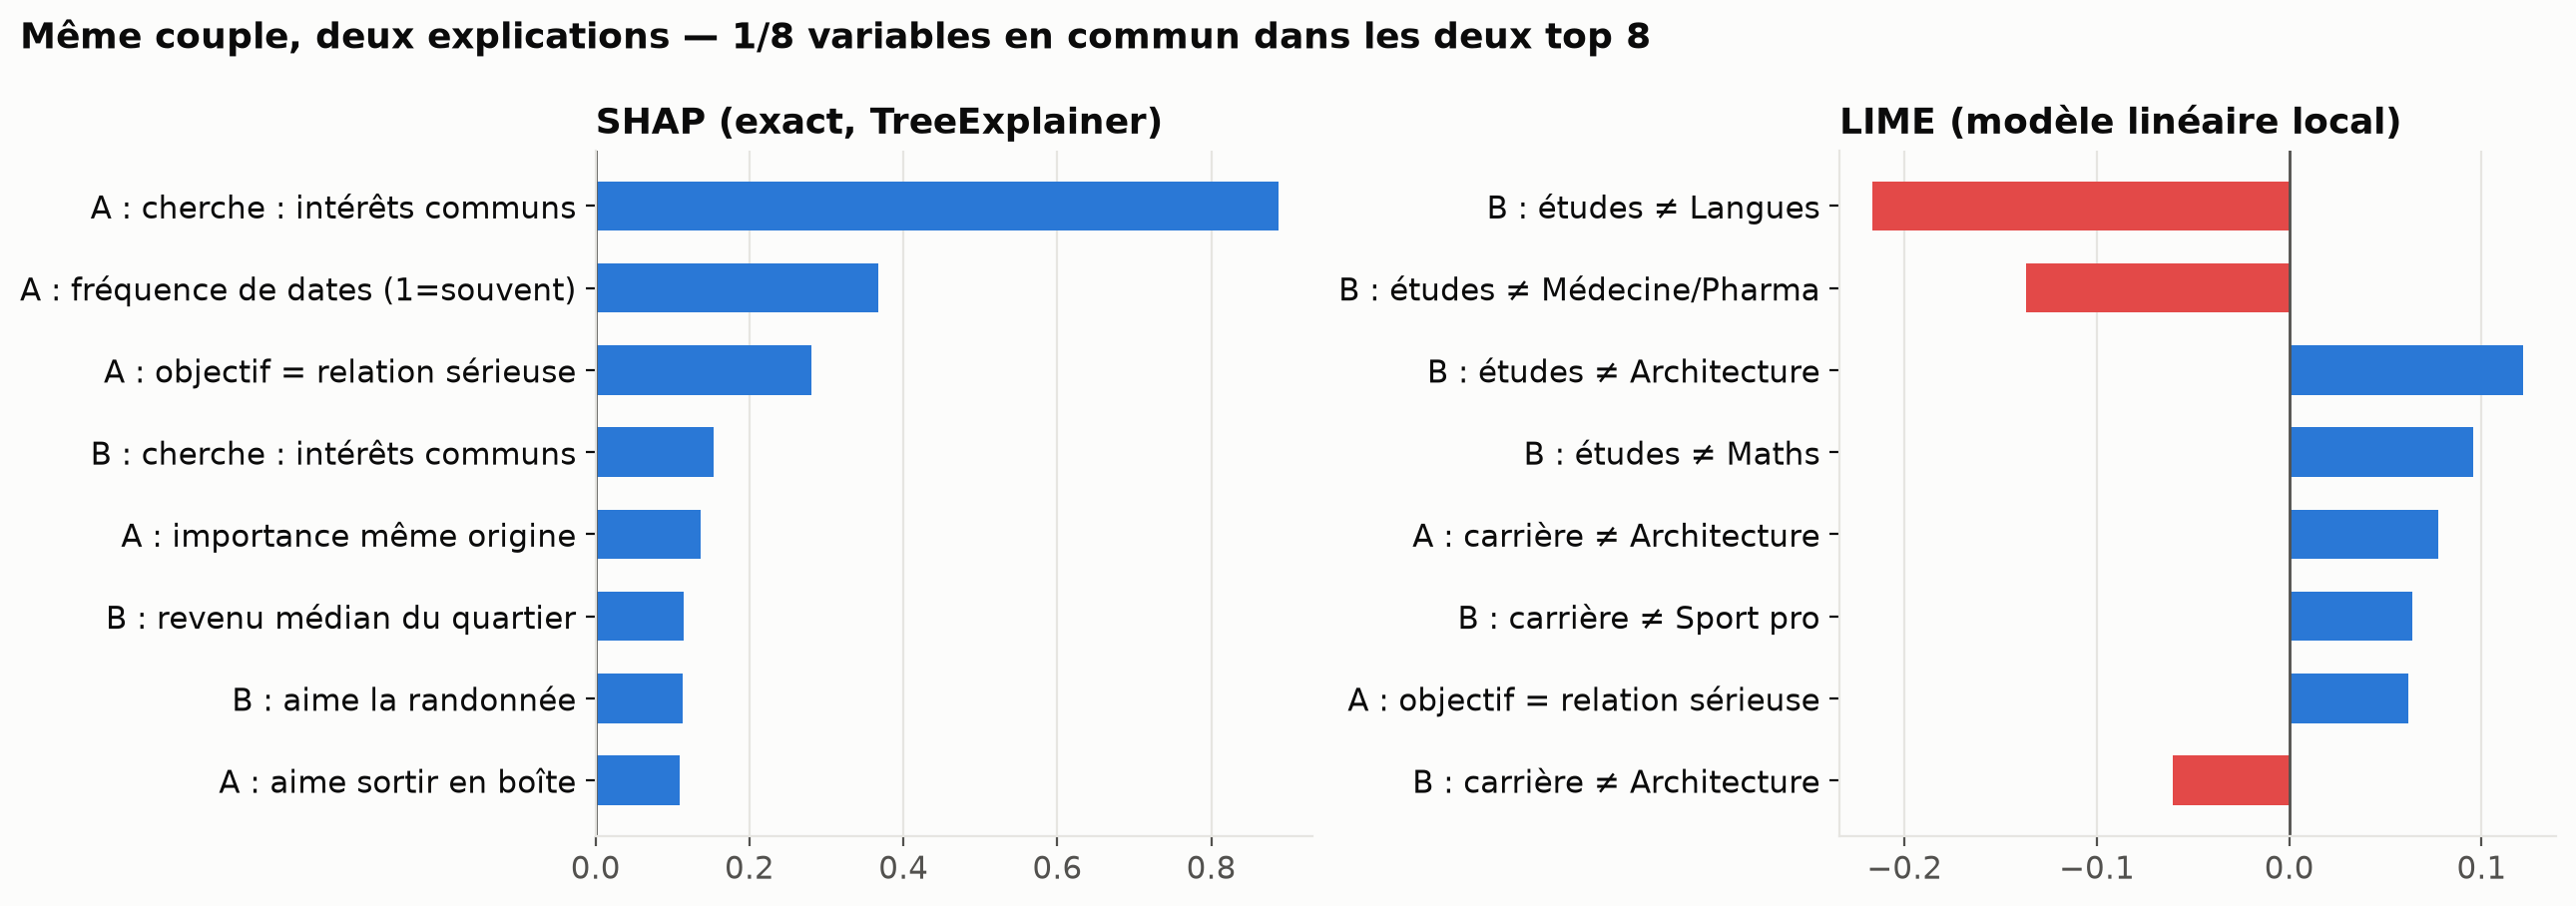

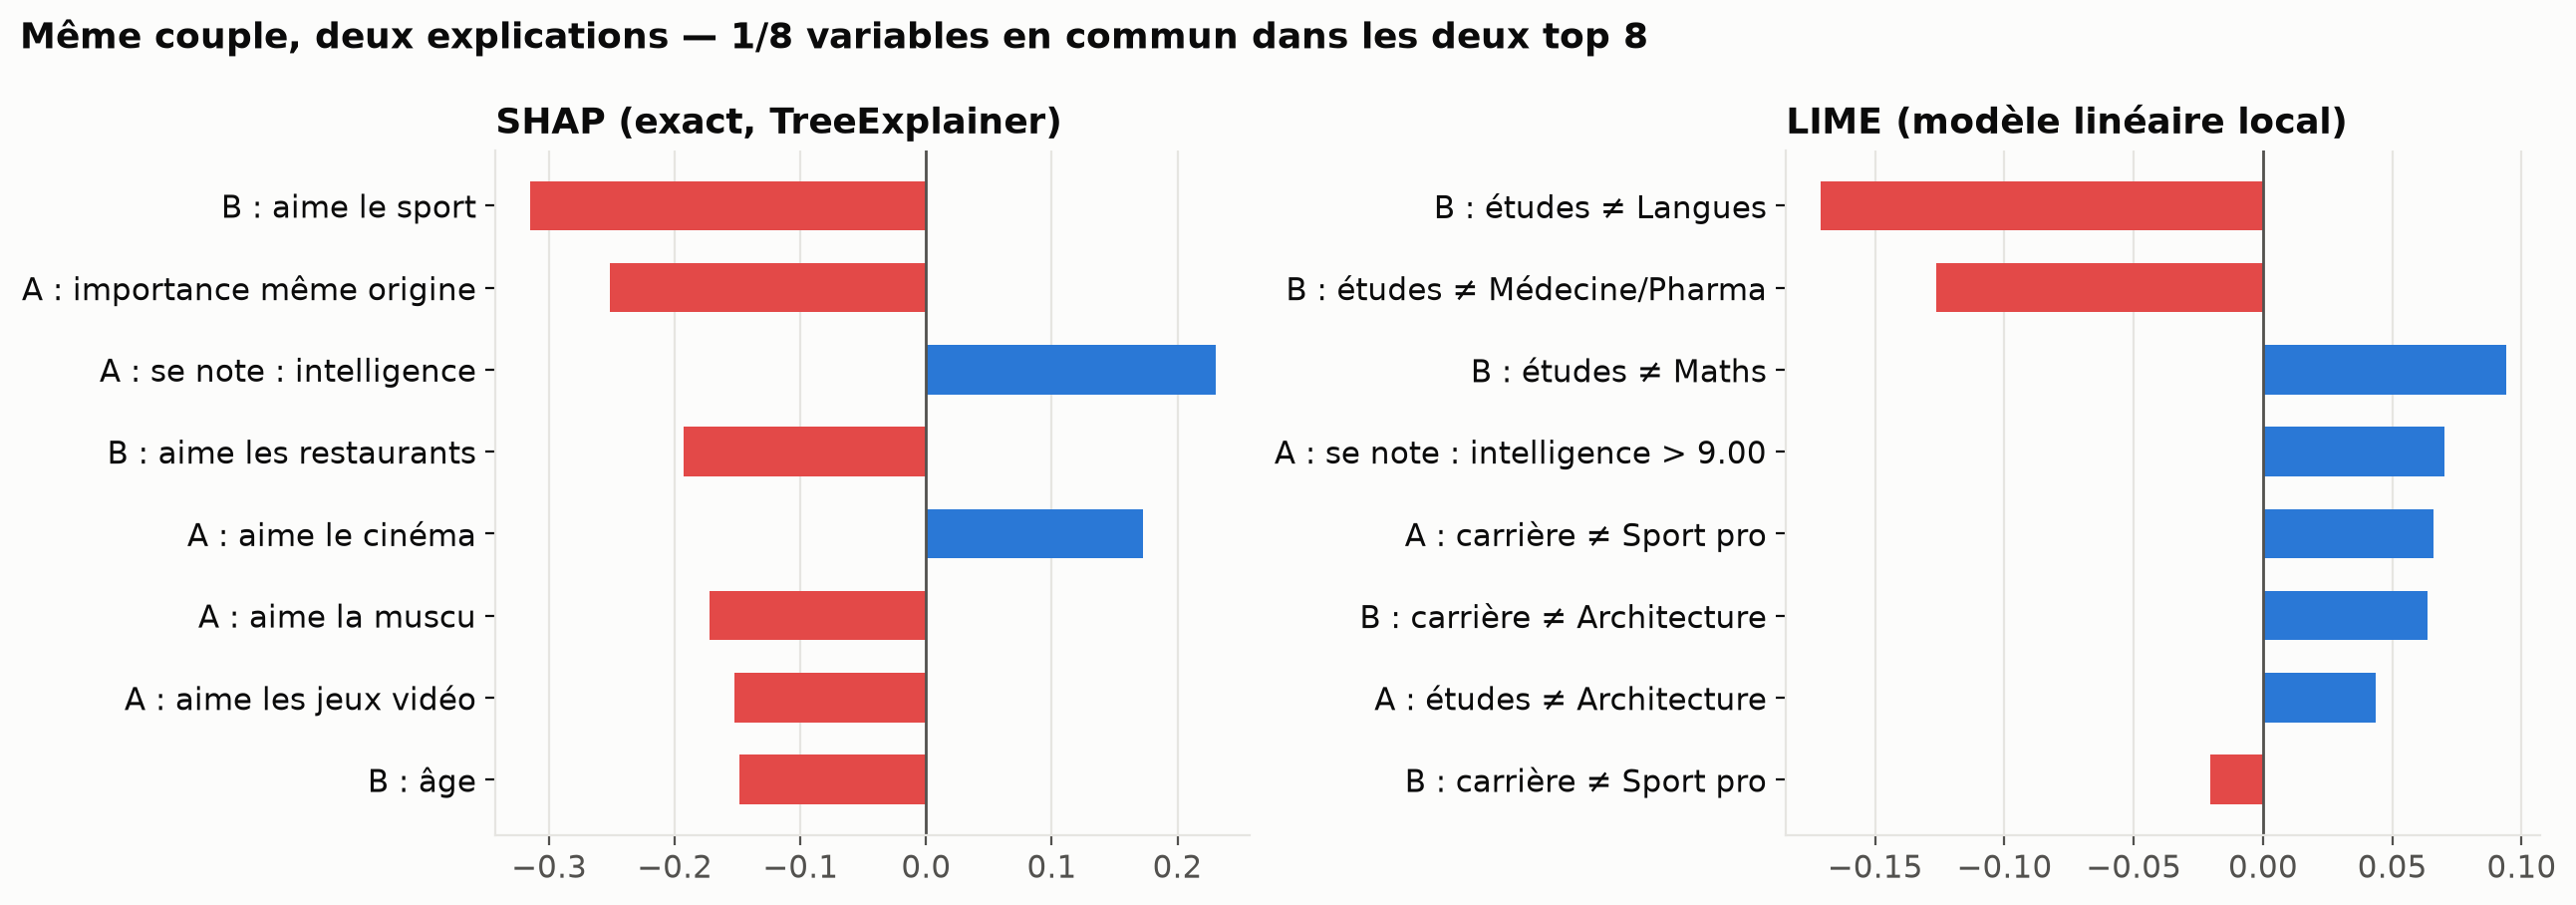

R² du modèle local LIME (fidélité locale) : {'oui_bien_predit': 0.045, 'non_bien_predit': 0.049}


In [7]:
lime_explainer, imputer, predict_fn = make_lime(train, F, xgb)
lime_scores = {}
for name, idx in examples.items():
    lime_list, r2 = lime_explain(lime_explainer, imputer, predict_fn, test.iloc[idx], F)
    lime_scores[name] = round(r2, 3)
    display(Image(plot_shap_vs_lime(exp.values[idx], lime_list, F, f"05_shap_vs_lime_{name}",
                                    "Même couple, deux explications")))
print("R² du modèle local LIME (fidélité locale) :", lime_scores)

In [8]:
agreement = shap_lime_agreement(exp, test, lime_explainer, imputer, predict_fn, F, n_couples=100, k=5)
agreement.to_csv(OUT_DIR / "shap_lime_agreement.csv", index=False)
agr = agreement[["feature_agreement", "rank1_agreement", "sign_agreement"]].mean().round(3).to_dict()
summary["shap_vs_lime"] = {**agr, "lime_r2_exemples": lime_scores, "n_couples": 100, "k": 5}
agr

{'feature_agreement': 0.316, 'rank1_agreement': 0.06, 'sign_agreement': 1.0}

**Lecture.** Sur 100 couples, SHAP et LIME ne partagent en moyenne qu'environ **un tiers** de leurs 5 variables
principales, et quasiment jamais la même variable n° 1. Quand ils s'accordent sur une variable, ils s'accordent
sur le sens de son effet. LIME a une fidélité locale très faible (R² de 0,05 à 0,1) : avec un signal diffus, un modèle
linéaire local n'approxime pas bien XGBoost, et le ré-échantillonnage crée des profils irréalistes (limites vues en cours).

**Conséquence produit** : pour l'explication affichée à l'utilisateur, on retient **SHAP** (exact pour les arbres,
additif, fondé sur des axiomes), pas LIME.

## 5. PDP et ICE — la forme des effets

La PDP (bleu) montre l'effet moyen d'une variable ; les courbes ICE (gris, une par couple, centrées) montrent si cet
effet est le même pour tout le monde (slides 88 et 121).

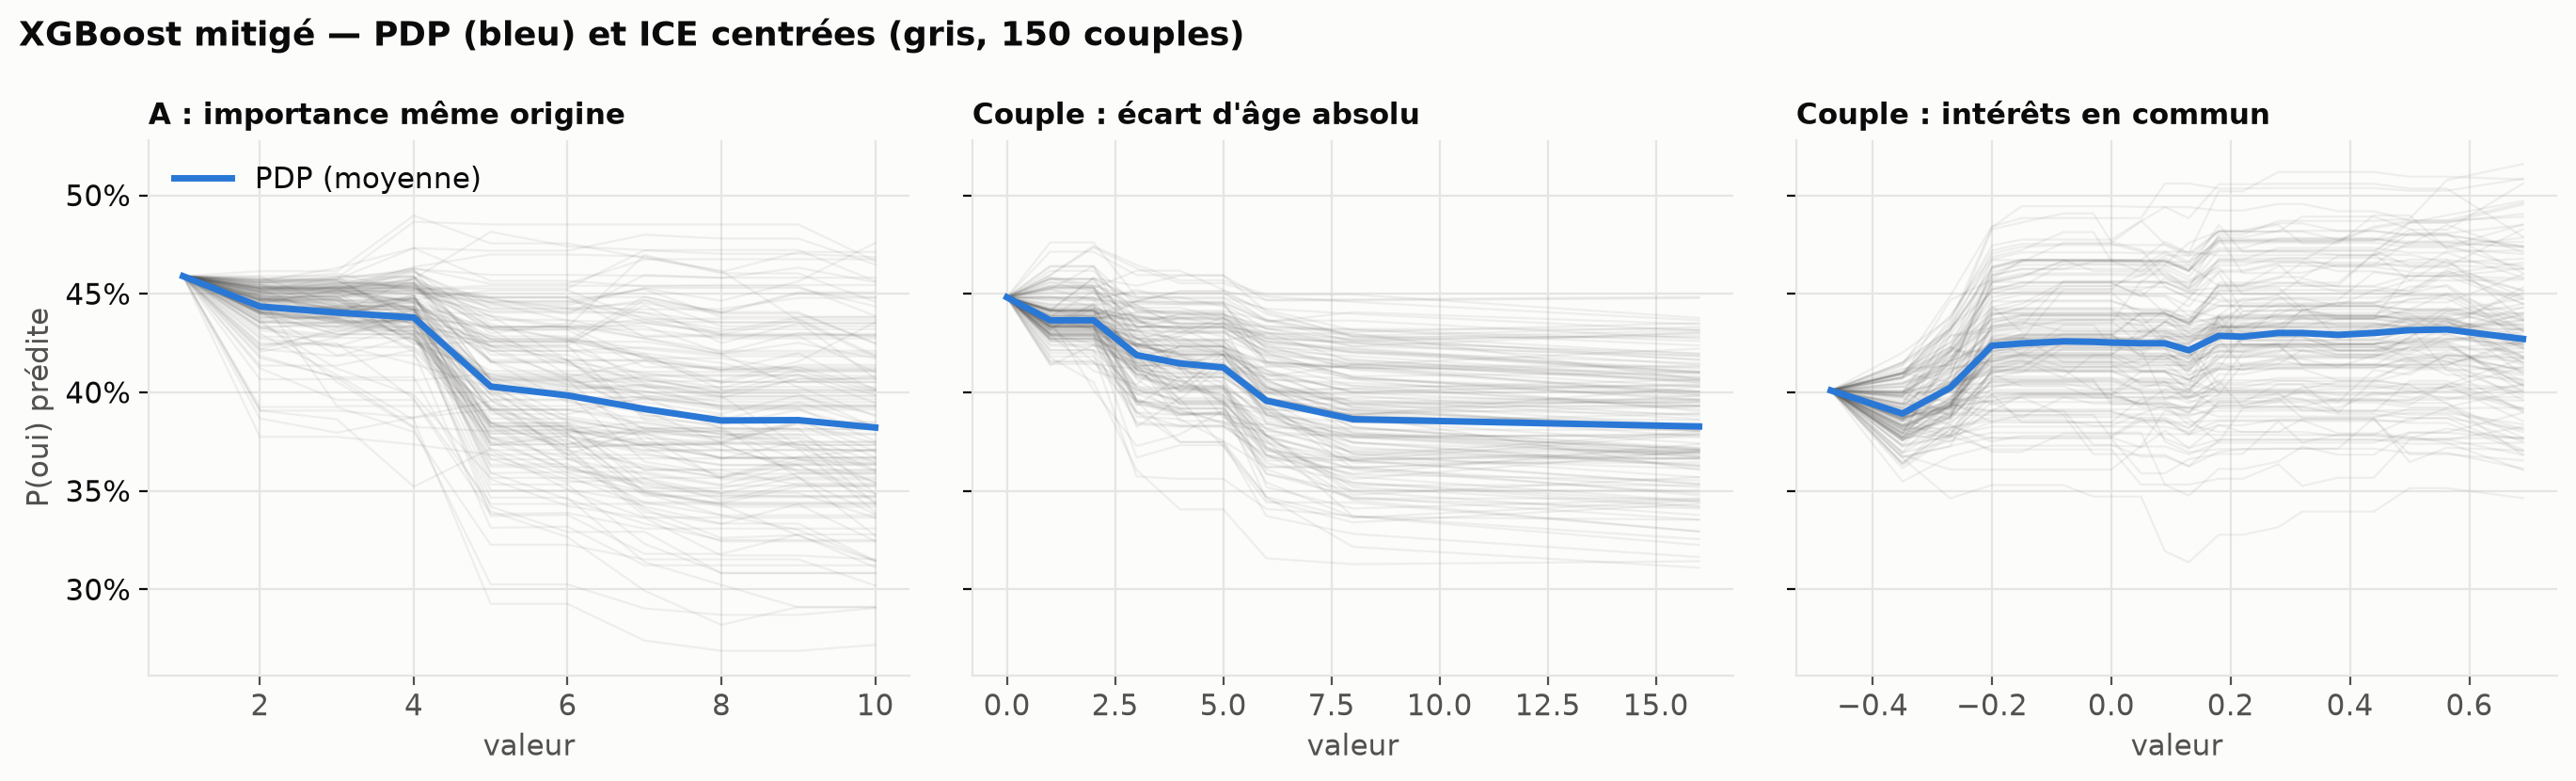

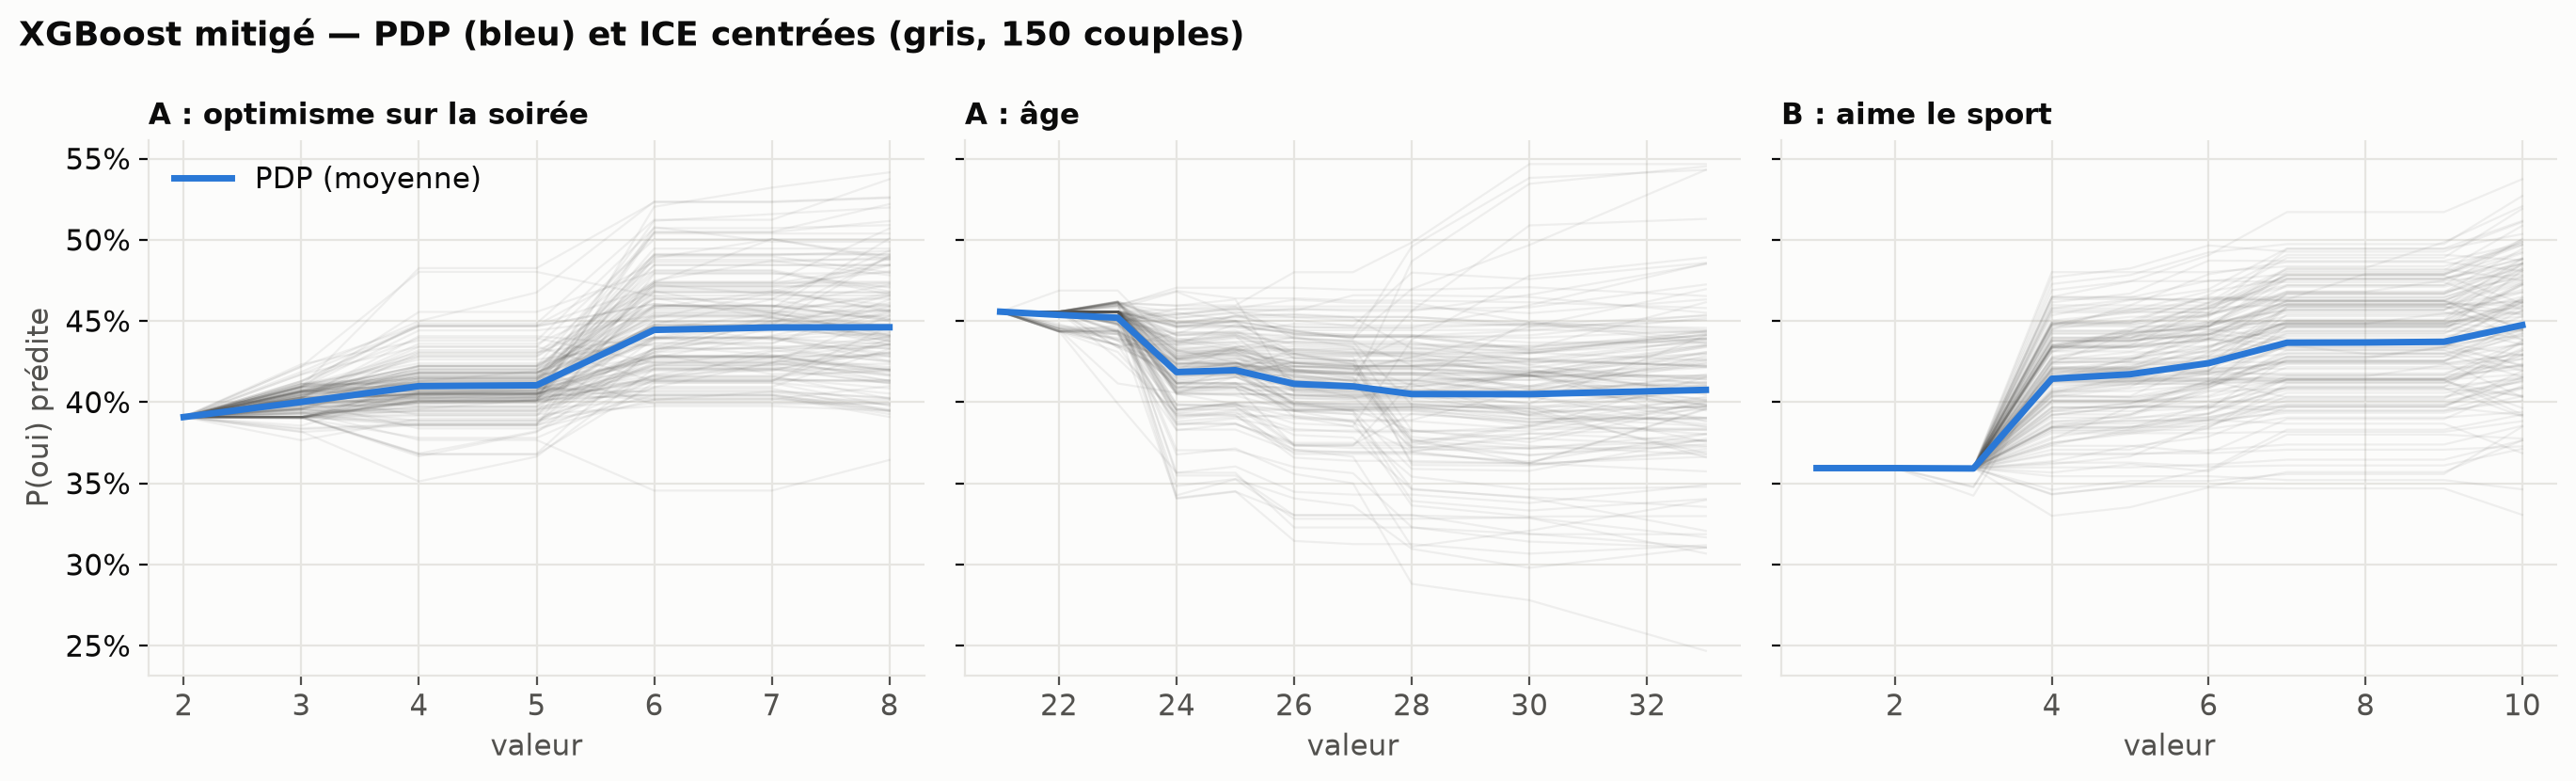

{'A : importance même origine': 7.7,
 "Couple : écart d'âge absolu": 6.6,
 'Couple : intérêts en commun': 4.3,
 'A : optimisme sur la soirée': 5.5,
 'A : âge': 5.1,
 'B : aime le sport': 8.8}

In [9]:
p1, pdp1 = plot_pdp_ice(xgb, X, ["imprace_A", "abs_age_diff", "int_corr"], "06_pdp_ice")
display(Image(p1))
p2, pdp2 = plot_pdp_ice(xgb, X, ["exphappy_A", "age_A", "sports_B"], "06b_pdp_ice_top")
display(Image(p2))
pdp_all = {**pdp1, **pdp2}
summary["pdp_amplitude_pp"] = {label(k): v["pdp_range_pp"] for k, v in pdp_all.items()}
summary["pdp_amplitude_pp"]

**Lecture.** Chaque variable ne déplace la probabilité moyenne que de quelques points (amplitude de la PDP),
et les ICE sont assez parallèles : les effets sont **modestes et homogènes**. Les variables de couple (écart d'âge,
intérêts communs), qu'on attendrait décisives pour une app de rencontre, ont des effets faibles.
Limite (slide 100) : la PDP suppose des variables indépendantes ; `abs_age_diff` est liée à l'âge de A et de B, donc
certains points de la grille correspondent à des couples peu réalistes.

## 6. Permutation importance — ce qui fait la **performance**, pas la prédiction

SHAP mesure ce que le modèle *utilise* ; la permutation importance mesure ce qui *améliore l'AUC* sur des données
jamais vues (slide 174). La décomposition exacte de l'AUC et du P&L par XPER est dans `05_performance.ipynb`.

In [10]:
perm = permutation_auc(xgb, X, test.dec, n_repeats=10)
perm.to_csv(OUT_DIR / "permutation_importance_auc.csv", index=False)
n_useful = int((perm.auc_drop > 2 * perm.auc_drop_std).sum())
summary["permutation"] = {"n_variables_utiles_2sd": n_useful, "n_variables": len(F),
                          "top5": list(perm.label.head(5))}
print(f"{n_useful} variables sur {len(F)} dégradent l'AUC de plus de 2 écarts-types quand on les permute")
perm.head(10)[["label", "auc_drop", "auc_drop_std"]].round(4)

35 variables sur 160 dégradent l'AUC de plus de 2 écarts-types quand on les permute


,label,auc_drop,auc_drop_std
0,A : optimisme sur la soirée,0.0153,0.0026
1,A : importance même origine,0.0128,0.0024
2,B : cherche : intérêts communs,0.0103,0.0025
3,A : aime les jeux vidéo,0.0099,0.0019
4,B : se note : humour,0.0083,0.0012
5,A : aime la muscu,0.0073,0.0014
6,B : aime la muscu,0.0070,0.0007
7,B : cherche : sincérité,0.0063,0.0020
8,A : aime le cinéma,0.0063,0.0028
9,B : aime les restaurants,0.0060,0.0016


**Lecture.** Environ un cinquième des variables contribue réellement à la performance hors échantillon.
Le classement diffère sensiblement de SHAP (voir section 9) : une variable peut être beaucoup utilisée par le
modèle sans l'aider à mieux prédire. Deux variables tiennent sur les deux mesures : l'**optimisme de A** et
l'**importance qu'A accorde à la même origine**.

## 7. Logit — le modèle white box

Coefficients standardisés : l'odds ratio se lit « pour +1 écart-type de la variable, les chances que A dise oui
sont multipliées par… ». Les intervalles de confiance viennent d'un **bootstrap de sessions d'entraînement**
(200 tirages), cohérent avec notre découpage par session. On donne aussi l'effet marginal moyen (AME, slide 35),
en points de probabilité.

Logit propre : 152 variables, AUC test 0.578 (logit_mitigated.joblib : 0.580)
22 variables sur 152 ont un effet significatif à 95 %


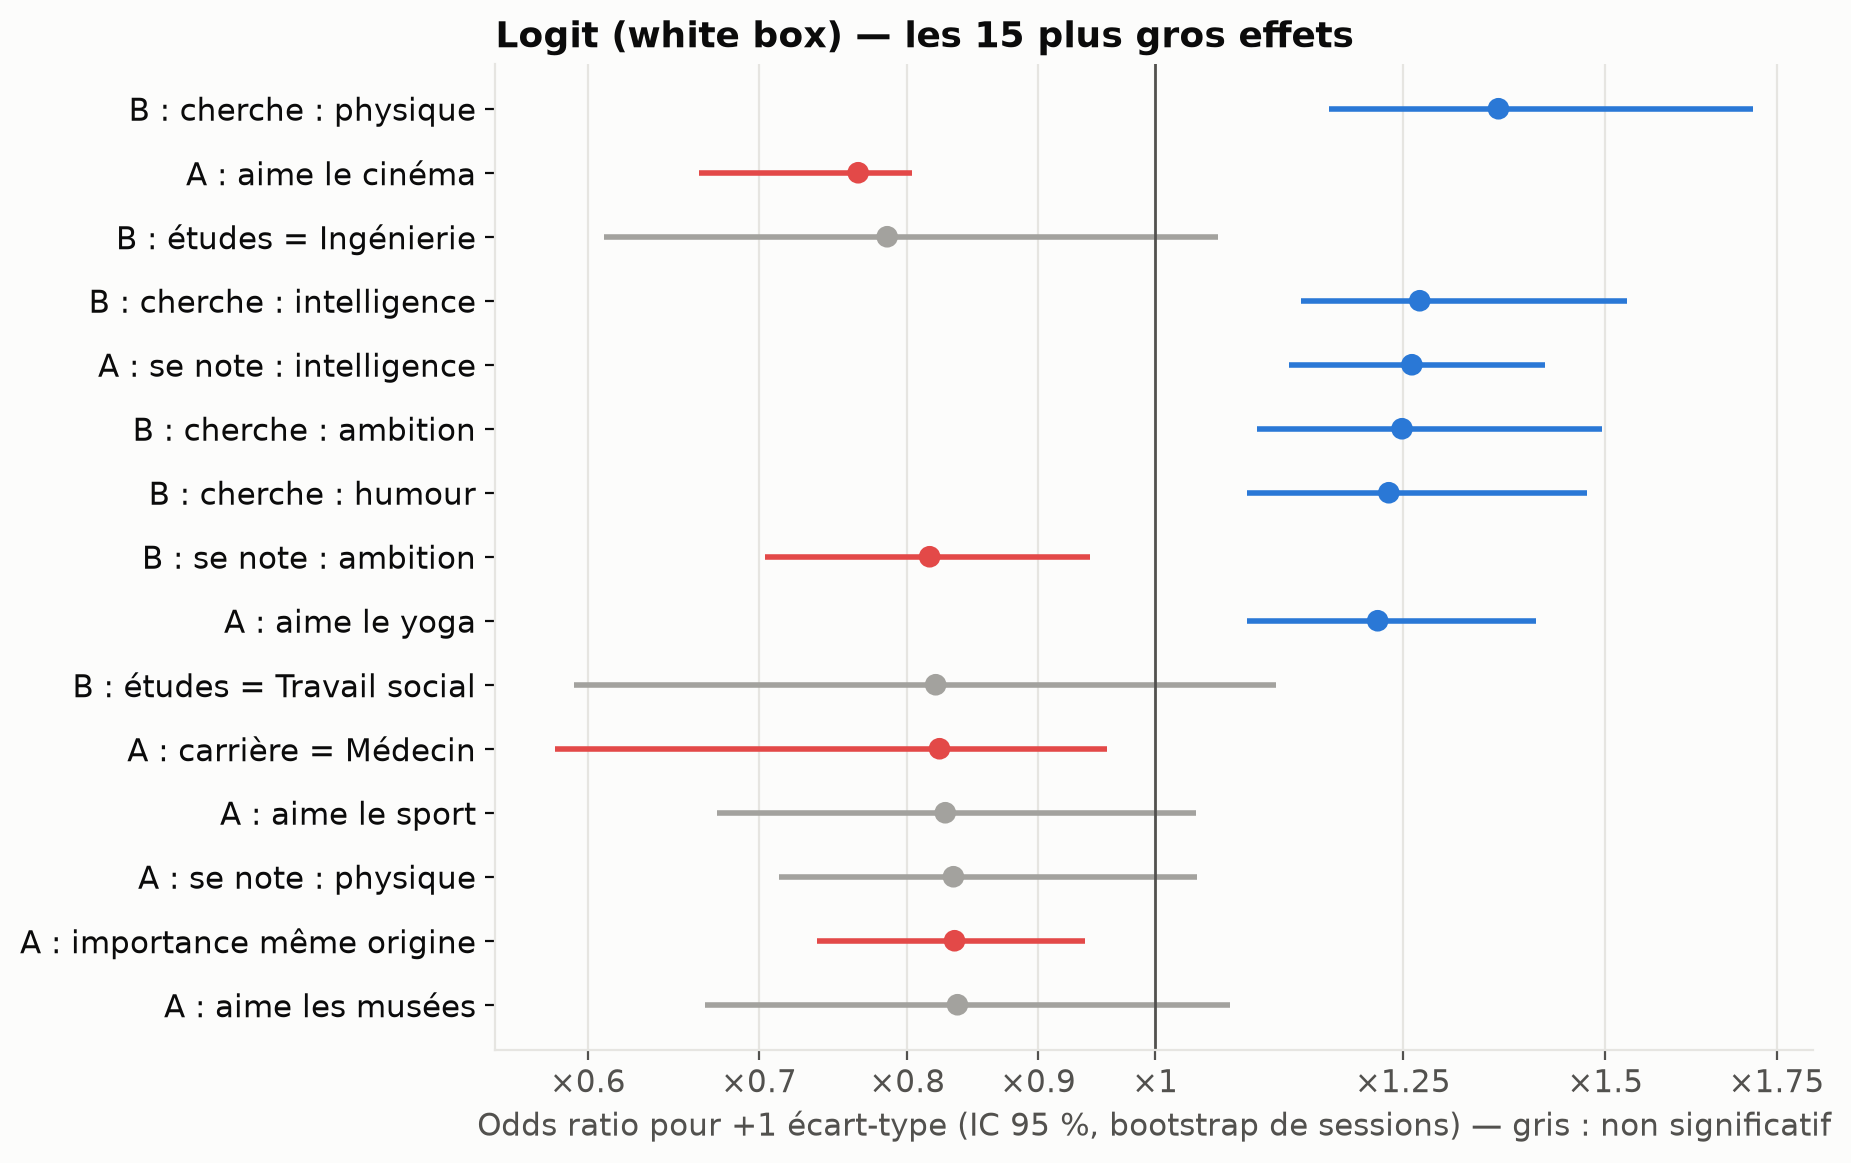

,label,odds_ratio_per_sd,or_ci_low,or_ci_high,ame_pp_per_sd,sign_stable_pct
0,B : cherche : physique,1.362,1.170,1.713,6.279,1.000
1,A : aime le cinéma,0.765,0.663,0.803,-5.429,1.000
2,B : études = Ingénierie,0.786,0.609,1.058,-4.899,0.940
3,B : cherche : intelligence,1.269,1.141,1.529,4.839,1.000
4,A : se note : intelligence,1.260,1.128,1.421,4.696,1.000
5,B : cherche : ambition,1.249,1.096,1.496,4.516,1.000
6,B : cherche : humour,1.234,1.086,1.476,4.274,0.995
7,B : se note : ambition,0.816,0.704,0.943,-4.122,1.000
8,A : aime le yoga,1.222,1.086,1.409,4.071,0.990
9,B : études = Travail social,0.821,0.593,1.115,-4.011,0.925


In [11]:
logit_clean, logit_feats = fit_clean_logit(train, fd)
auc_clean = roc_auc_score(test.dec, logit_clean.predict_proba(test[logit_feats])[:, 1])
logit_tab = logit_table(logit_clean, logit_feats, train, test, n_boot=200)
logit_tab.to_csv(OUT_DIR / "logit_odds_ratios.csv", index=False)
summary["logit"] = {"auc_test": round(auc_clean, 3), "n_variables": len(logit_feats),
                    "n_significatives_95": int(logit_tab.significant_95.sum())}
print(f"Logit propre : {len(logit_feats)} variables, AUC test {auc_clean:.3f} "
      f"(logit_mitigated.joblib : {roc_auc_score(test.dec, test.proba_logit_mitigated):.3f})")
print(f"{logit_tab.significant_95.sum()} variables sur {len(logit_feats)} ont un effet significatif à 95 %")
display(Image(plot_logit_forest(logit_tab)))
logit_tab.head(12)[["label", "odds_ratio_per_sd", "or_ci_low", "or_ci_high", "ame_pp_per_sd", "sign_stable_pct"]].round(3)

**Lecture.** Le logit est le seul modèle dont on peut lire directement chaque effet, avec son incertitude.
Environ 15 % des variables ont un effet significatif ; les plus forts déplacent la probabilité de 4 à 6 points par
écart-type. On retrouve des variables communes avec XGBoost : **A aime le cinéma → moins de oui**, **A accorde de
l'importance à la même origine → moins de oui** (OR ≈ 0,84, significatif).

⚠️ Les préférences de B (« B cherche : physique / ambition ») sont en partie des **indices du genre de B**
(section 10) : leur coefficient ne se lit pas comme un pur effet de préférence.

## 8. TabICL — interpréter un modèle qu'on ne peut pas ouvrir

TabICL ne tourne que sur GPU : on n'a que ses prédictions. On l'approxime par un **modèle surrogate** entraîné à
reproduire ces prédictions (slide 84), et on mesure sa **fidélité** par validation croisée entre sessions.
Seules les lignes test sont utilisées : sur les lignes d'entraînement, TabICL les a « vues » en contexte
(AUC ≈ 0,92 contre 0,63 en test).

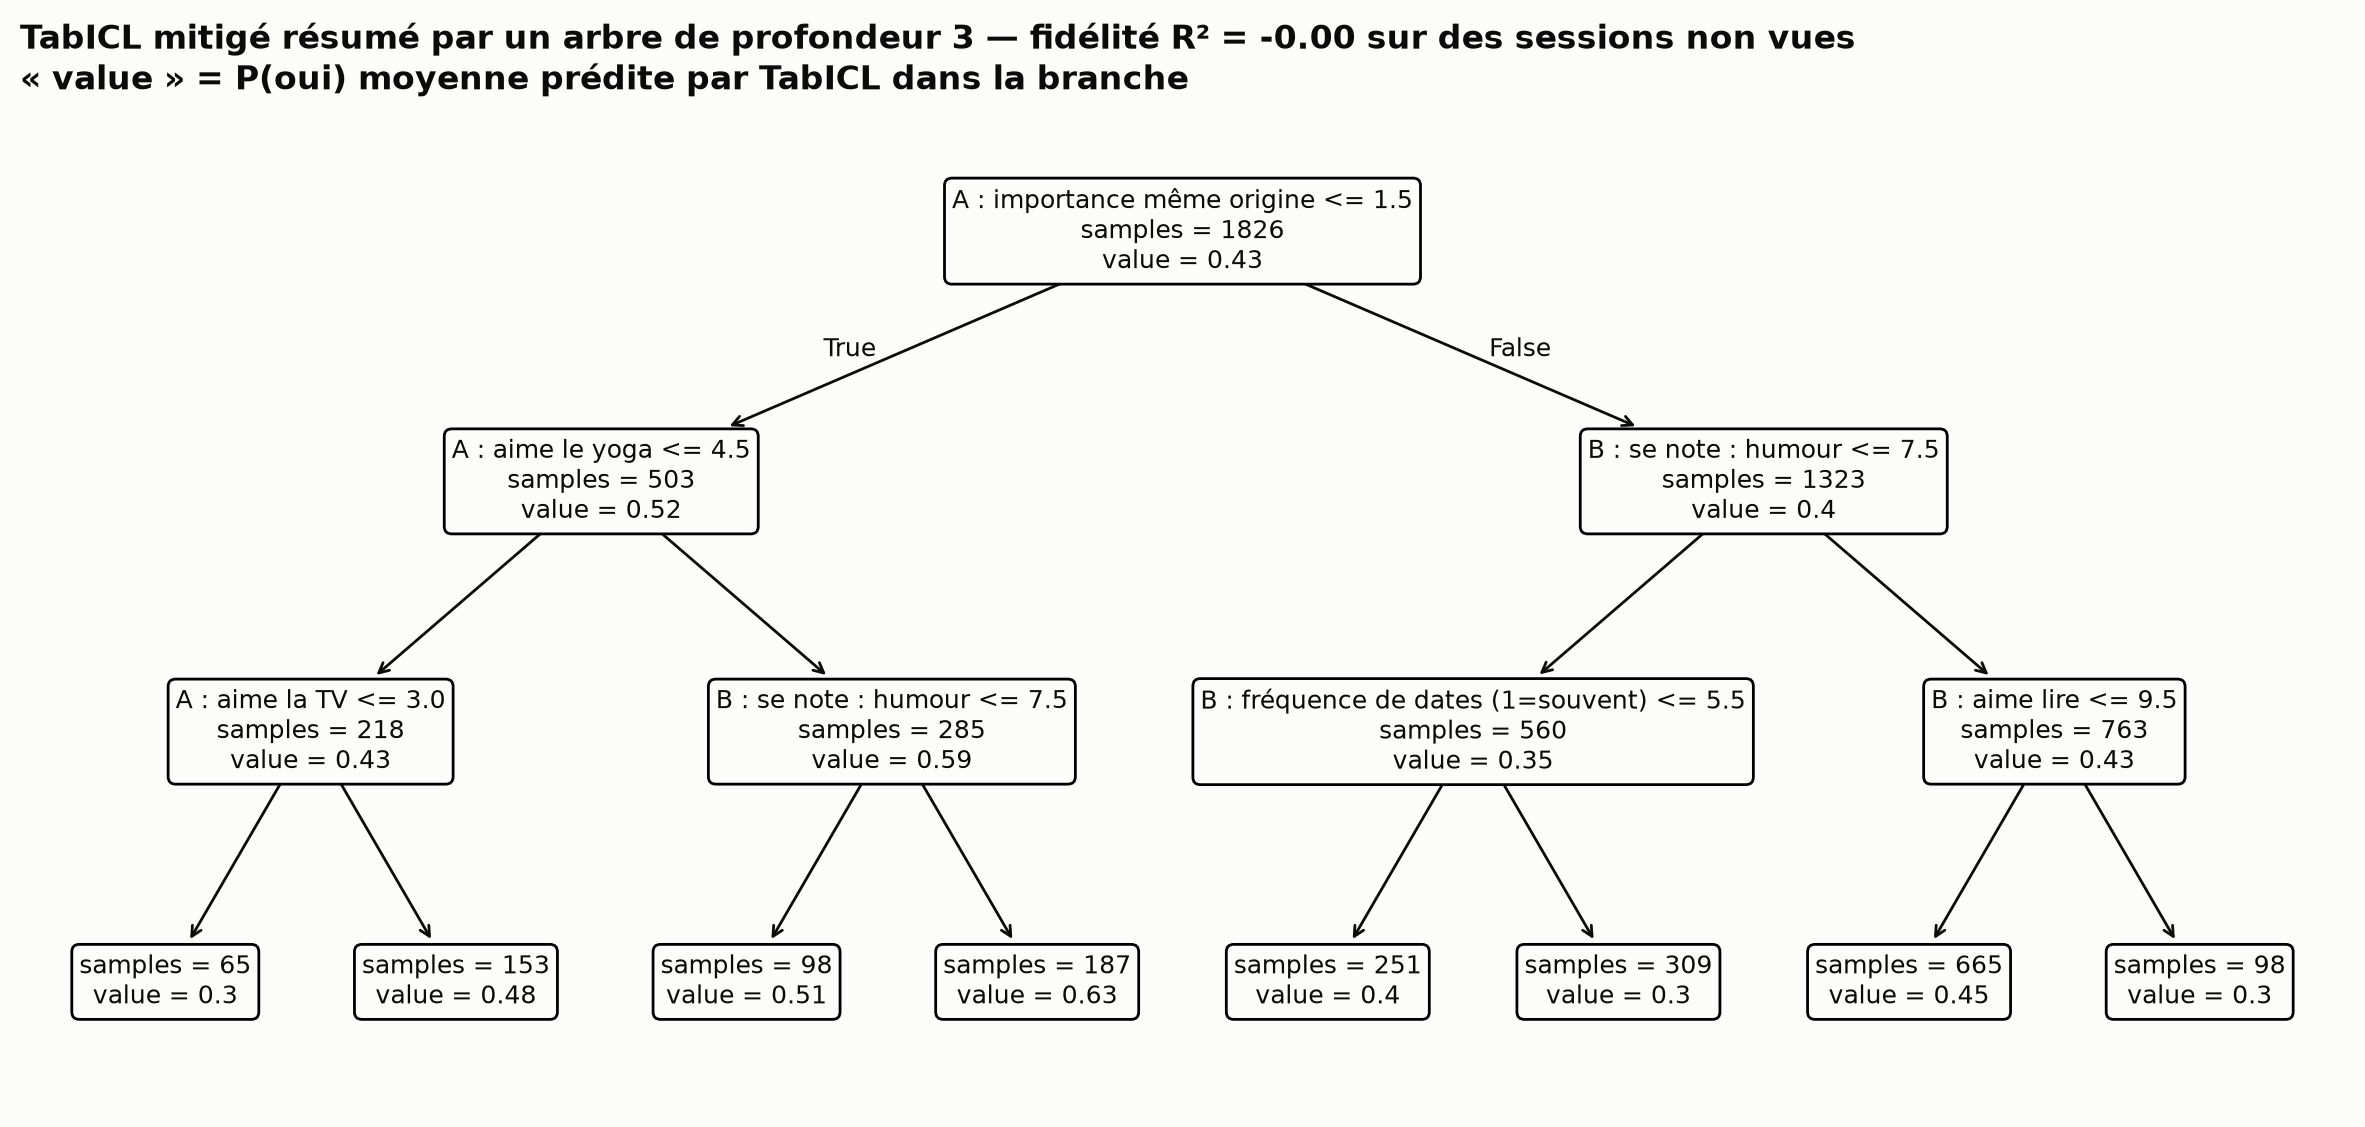

Arbre lisible (profondeur 3) : {'r2_in_sample': 0.328, 'r2_cv_by_session': -0.0, 'spearman_cv': np.float64(0.273), 'auc_surrogate_vs_dec': np.float64(0.573), 'auc_tabicl_vs_dec': np.float64(0.626)}
Surrogate XGBoost (profondeur 2) : {'r2_cv_by_session': 0.342, 'spearman_cv': np.float64(0.559)}


,label,importance
0,A : importance même origine,0.0216
1,A : aime le yoga,0.0207
2,A : aime les jeux vidéo,0.0171
3,B : cherche : intérêts communs,0.0160
4,B : aime la muscu,0.0160
5,B : aime le sport,0.0129
6,B : fréquence de dates (1=souvent),0.0123
7,A : cherche : intérêts communs,0.0116
8,A : cherche : ambition,0.0115
9,B : aime les restaurants,0.0108


In [12]:
tree, fid_tree, tree_imp = tabicl_surrogate(test, F, depth=3)
display(Image(plot_surrogate(tree, F, fid_tree)))
xgb_sur, fid_xgb, sur_imp = tabicl_surrogate_xgb(test, F)
sur_imp.to_csv(OUT_DIR / "tabicl_surrogate_importance.csv", index=False)
summary["tabicl_surrogate"] = {"arbre_profondeur_3": fid_tree, "xgb_profondeur_2": fid_xgb,
                               "top5_xgb_surrogate": list(sur_imp.label.head(5))}
print("Arbre lisible (profondeur 3) :", fid_tree)
print("Surrogate XGBoost (profondeur 2) :", fid_xgb)
sur_imp.head(10)[["label", "importance"]].round(4)

**Lecture.** C'est l'**illusion d'interprétabilité** dont parle le cours : l'arbre de profondeur 3 est parfaitement
lisible, mais ne reproduit pas du tout TabICL sur une session qu'il n'a pas vue (R² ≈ 0). Un surrogate plus souple
(XGBoost de profondeur 2) capte environ un tiers de la variance des prédictions de TabICL : c'est la meilleure
fenêtre qu'on ait sur ce modèle, et elle reste partielle. On retrouve encore **l'importance qu'A accorde à la même
origine** parmi les variables principales.

**Pour la recommandation** : TabICL a la meilleure AUC (0,626), mais c'est le modèle qu'on sait le moins expliquer
à un utilisateur ou à un régulateur.

## 9. Les modèles et les méthodes racontent-ils la même histoire ?

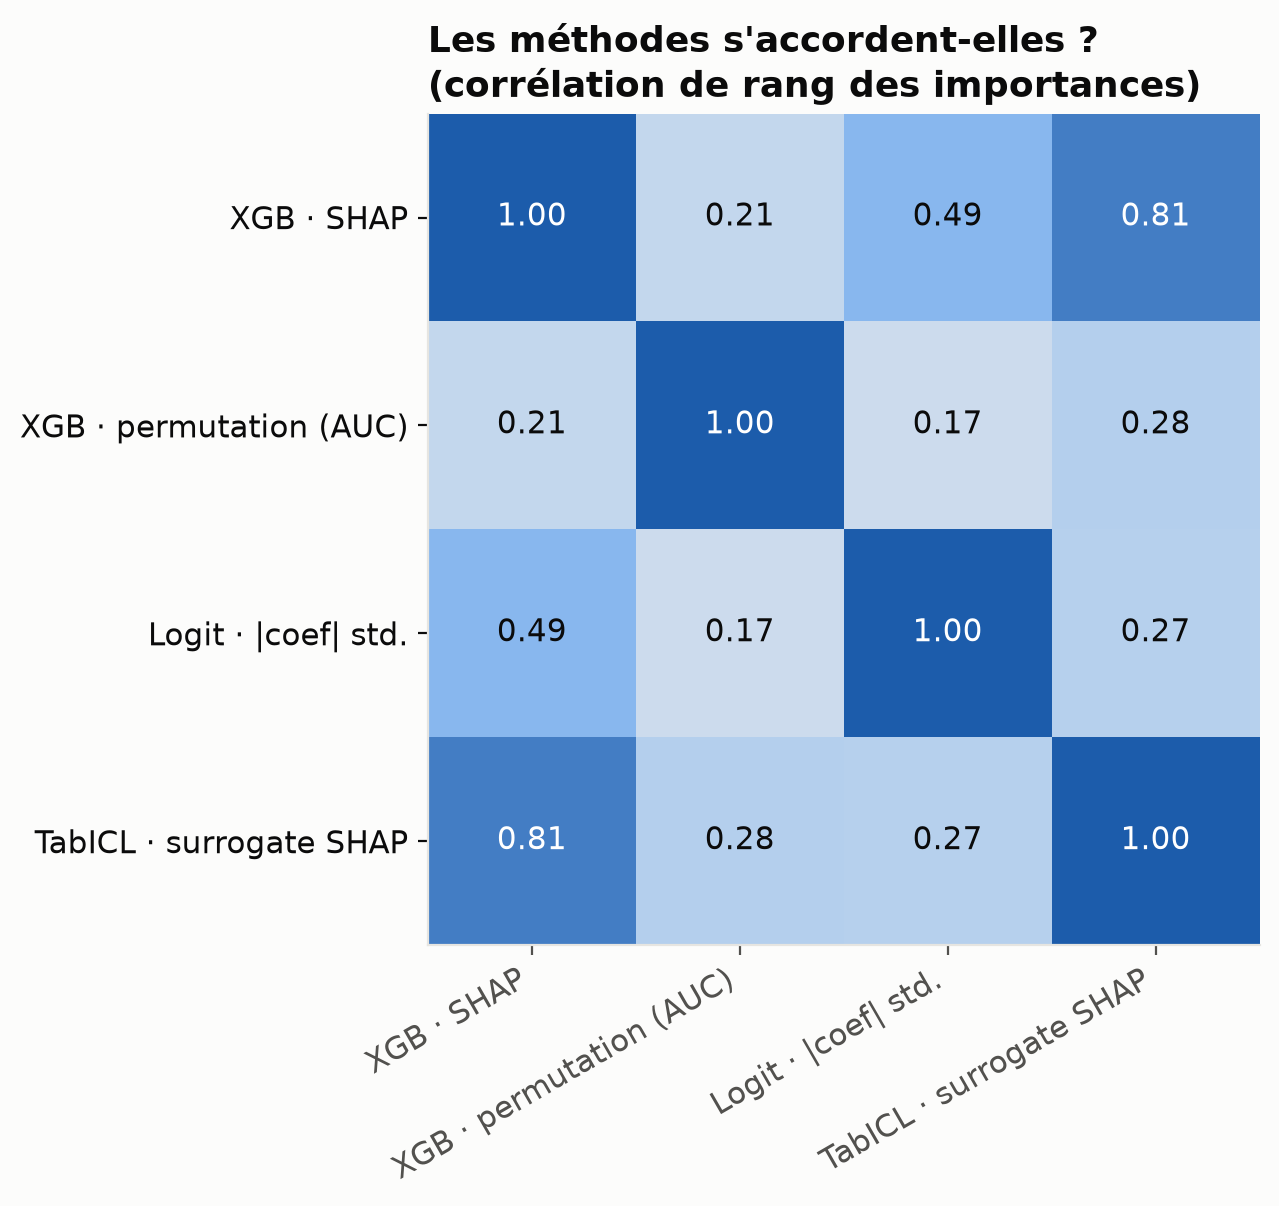

,label,n_methods_topk,XGB · SHAP,XGB · permutation (AUC),Logit · |coef| std.,TabICL · surrogate SHAP
feature,,,,,,
imprace_A,A : importance même origine,4,1,2,14,1
clubbing_A,A : aime sortir en boîte,3,13,13,41,14
exphappy_A,A : optimisme sur la soirée,3,5,1,16,15
gaming_A,A : aime les jeux vidéo,3,2,3,27,3
movies_A,A : aime le cinéma,3,3,8,2,61
yoga_A,A : aime le yoga,3,11,36,9,2


In [13]:
rho, consensus = model_agreement(imp, logit_tab, sur_imp, perm, k=15)
consensus.to_csv(OUT_DIR / "consensus_variables.csv")
display(Image(plot_agreement(rho)))
summary["accord_methodes_spearman"] = rho.to_dict()
summary["variables_consensus"] = list(consensus.label)
consensus

**Lecture.** Deux constats :

- **Les deux boîtes noires regardent la même chose** : l'importance SHAP de XGBoost et celle du surrogate de TabICL
  sont très corrélées (≈ 0,8). Nuance : le surrogate est lui-même un modèle d'arbres, ce qui rapproche mécaniquement
  les deux classements. Le logit, lui, ne les rejoint que partiellement (≈ 0,5, et ≈ 0,3 avec TabICL).
- **Ce que le modèle utilise n'est pas ce qui le rend performant** : la permutation importance (contribution à l'AUC)
  est peu corrélée à toutes les autres mesures (≈ 0,2). Beaucoup de variables influencent le score sans améliorer
  la prédiction : du bruit que le modèle a appris.

Seules six variables apparaissent dans le top 15 d'au moins trois méthodes sur quatre, **toutes du côté de A** :
ce sont les explications qu'on peut présenter comme robustes.

## 10. Le genre, variable invisible mais reconstructible

Le genre n'entre jamais dans les modèles. Mais les préférences déclarées diffèrent fortement entre hommes et femmes
(les hommes pondèrent plus le physique, les femmes l'ambition et l'intelligence). Peut-on deviner le genre à partir
des variables du modèle ?

In [14]:
gender = gender_proxy_check(train, test, F, ["proba_logit_mitigated", "proba_xgb_mitigated", "proba_tabicl_mitigated"])
summary["genre"] = gender
gender

{'auc_devine_genre_B': np.float64(0.815),
 'auc_devine_genre_A': np.float64(0.814),
 'taux_recommandation_top50pct': {'proba_logit_mitigated': {'femmes': np.float64(0.531),
   'hommes': np.float64(0.469)},
  'proba_xgb_mitigated': {'femmes': np.float64(0.583),
   'hommes': np.float64(0.417)},
  'proba_tabicl_mitigated': {'femmes': np.float64(0.577),
   'hommes': np.float64(0.423)},
  'oui_reels': {'femmes': np.float64(0.55), 'hommes': np.float64(0.308)}}}

**Lecture.** Oui : les seules variables de B permettent de deviner son genre avec une AUC d'environ 0,8. Si l'app
recommande la moitié des profils les mieux notés, les candidates sont nettement plus recommandées que les candidats.
Cela va dans le sens des décisions réelles (dans les données, les candidates reçoivent 55 % de oui contre 31 %
pour les candidats) : le modèle **reproduit** une préférence humaine qu'il ne « voit » pas directement.
C'est exactement le mécanisme de proxy que la FPDP cherche à détecter : **l'audit de fairness devrait couvrir le
genre, pas seulement l'origine** (à transmettre au bloc fairness).

## 11. Synthèse — messages pour la soutenance

In [15]:
summary["modele_explique"] = "xgb_mitigated (+ logit propre, + TabICL mitigé via surrogate)"
(OUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False, default=float))
print(json.dumps({k: summary[k] for k in ["shap_share_by_side", "borne_selectivite_popularite", "shap_vs_lime",
                                          "tabicl_surrogate", "variables_consensus"]},
                 indent=2, ensure_ascii=False, default=float))

{
  "shap_share_by_side": {
    "A (décideur)": 0.5260000228881836,
    "B (candidat)": 0.4359999895095825,
    "Couple": 0.03799999877810478
  },
  "borne_selectivite_popularite": {
    "auc_selectivite_A": 0.763,
    "auc_popularite_B": 0.744,
    "auc_A_plus_B": 0.839
  },
  "shap_vs_lime": {
    "feature_agreement": 0.316,
    "rank1_agreement": 0.06,
    "sign_agreement": 1.0,
    "lime_r2_exemples": {
      "oui_bien_predit": 0.045,
      "non_bien_predit": 0.049
    },
    "n_couples": 100,
    "k": 5
  },
  "tabicl_surrogate": {
    "arbre_profondeur_3": {
      "r2_in_sample": 0.328,
      "r2_cv_by_session": -0.0,
      "spearman_cv": 0.273,
      "auc_surrogate_vs_dec": 0.573,
      "auc_tabicl_vs_dec": 0.626
    },
    "xgb_profondeur_2": {
      "r2_cv_by_session": 0.342,
      "spearman_cv": 0.559
    },
    "top5_xgb_surrogate": [
      "A : importance même origine",
      "A : aime le yoga",
      "A : aime les jeux vidéo",
      "B : cherche : intérêts communs",
      

1. **Le modèle apprend qui est sélectif et qui est populaire, pas l'alchimie.** ~53 % de l'importance vient de A,
   ~44 % de B, ~4 % du couple. Le comportement (sélectivité et popularité observées) prédirait bien mieux que le
   profil : c'est le *cold start* des apps de rencontre.
2. **Les explications sont diffuses et fragiles.** Aucune variable ne pèse plus de ~3 % ; SHAP et LIME ne
   s'accordent que sur un tiers des variables ; ce que le modèle utilise ne recoupe guère ce qui le rend
   performant. Seules six variables sont robustes, toutes côté A : optimisme sur la soirée, importance accordée à
   la même origine, goût pour le cinéma, les jeux vidéo, le yoga et les sorties en boîte.
3. **Une préférence raciale déclarée est la variable n° 1.** Retirer les proxies de l'origine de B ne suffit pas :
   l'importance que A accorde à la même origine pilote la recommandation. Choix à trancher avec la fairness.
4. **Le genre est reconstructible** (AUC ≈ 0,8) : l'audit de fairness doit couvrir le genre.
5. **Interprétabilité par modèle** : logit = lisible et avec incertitude ; XGBoost = bien expliqué par SHAP (exact,
   additif, affichable dans l'app) ; TabICL = meilleure AUC, mais seulement un tiers de ses prédictions expliqué
   par le meilleur surrogate. **Pour une IA de confiance, l'écart d'AUC (0,61 → 0,63, non significatif selon la
   stabilité) ne compense pas cette perte d'explicabilité.**